# Assignment: Systematischer Modellvergleich
## Telco Customer Churn — klassische Modelle vs. neuronale Netze

**Kurs:** Maschinelles Lernen mit Python, scikit-learn und Keras · DHBW Stuttgart · SS 2026  
**Gruppe:** ??? Joel Martinez  
**Datensatz:** Telco Customer Churn (~7.000 Kunden, 20 Features)  
**Aufgabe:** Binäre Klassifikation — kündigt ein Kunde seinen Vertrag? (`Churn` = Yes/No)

---

### Zielsetzung
Wir führen eine vollständige ML-Pipeline durch und vergleichen **fünf Modelle** systematisch.
Im Fokus steht ein **methodisch sauberes, nachvollziehbares und kritisch reflektiertes** Vorgehen —
nicht die maximale Accuracy. Jede Entscheidung wird in einer Markdown-Zelle begründet.

### Die fünf Modelle
| # | Modell | Typ |
|---|--------|-----|
| 1 | Logistic Regression | klassisch |
| 2 | Decision Tree / Random Forest / XGBoost *(eines auswählen)* | klassisch |
| 3 | k-NN / SVM *(eines auswählen)* | klassisch |
| 4 | MLP Variante A (Keras) | neuronal |
| 5 | MLP Variante B (Keras) | neuronal |

## Setup — Bibliotheken und Konfiguration

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproduzierbarkeit: feste Zufallszahl für alle Modelle/Splits
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Einheitliche Plot-Optik
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

print("Setup abgeschlossen.")

Setup abgeschlossen.


---
# Schritt 1 — Datenanalyse

Ziel: den Datensatz **verstehen**, bevor wir Entscheidungen treffen. Wir verschaffen uns einen
Überblick über Form, Datentypen und fehlende Werte, dokumentieren die Verteilung der Zielvariable
und erstellen aussagekräftige Visualisierungen.

### 1.1 Datensatz laden und erster Überblick

In [ ]:
# Quelle: Claude
import os, glob

# Datensatz laden mit drei Fallbacks:
CSV_NAME = "Kaggle-Dataset.csv"
kandidaten = ["Data/Kaggle-Dataset.csv", CSV_NAME, f"/content/{CSV_NAME}"]
pfad = next((p for p in kandidaten if os.path.exists(p)), None)

# 2) kagglehub-Download
if pfad is None:
    try:
        import kagglehub
        download_dir = kagglehub.dataset_download("blastchar/telco-customer-churn")
        csvs = glob.glob(os.path.join(download_dir, "*.csv"))
        pfad = csvs[0] if csvs else None
        print("Download-Verzeichnis:", download_dir)
    except Exception as e:
        print("kagglehub nicht verfügbar/fehlgeschlagen:", e)

# 3) manueller Upload in Colab
if pfad is None:
    try:
        from google.colab import files
        print("Bitte die CSV-Datei hochladen ...")
        hochgeladen = files.upload()
        pfad = list(hochgeladen.keys())[0]
    except ModuleNotFoundError:
        raise FileNotFoundError(
            "CSV nicht gefunden. Lege die Datei lokal ab oder installiere kagglehub."
        )

df = pd.read_csv(pfad)
print("Geladen aus:", pfad)
print("Form (Zeilen, Spalten):", df.shape)
df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Download-Verzeichnis: /kaggle/input/telco-customer-churn
Geladen aus: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Form (Zeilen, Spalten): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Die Spalte `customerID` ist nur eine eindeutige Kennung ohne Vorhersagekraft —
wir merken sie zum **Entfernen** vor (passiert im Preprocessing, Schritt 2).

In [21]:
# Datentypen aller Spalten
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 1.2 Datentypen prüfen — der Sonderfall `TotalCharges`

`df.info()` zeigt `TotalCharges` als **`object` (Text)**, obwohl es eine Geldsumme ist.
Ursache: Bei Neukunden (`tenure = 0`) steht statt einer Zahl ein **Leerstring `" "`**.
Wir machen das Problem sichtbar — die **Behandlung** erfolgt bewusst erst in Schritt 2 (Preprocessing).

In [22]:
# Versuch, TotalCharges in Zahlen zu wandeln -> Leerstrings werden zu NaN
total_charges_num = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_leer = total_charges_num.isna().sum()
print(f"TotalCharges, die NICHT als Zahl interpretierbar sind: {n_leer}")

# Zusammenhang prüfen: Sind das genau die Neukunden mit tenure = 0?
print("\ntenure-Werte dieser Zeilen:")
print(df.loc[total_charges_num.isna(), "tenure"].value_counts())

TotalCharges, die NICHT als Zahl interpretierbar sind: 11

tenure-Werte dieser Zeilen:
tenure
0    11
Name: count, dtype: int64


**Beobachtung:** Die nicht-konvertierbaren Werte gehören ausschließlich zu Kunden mit `tenure = 0`
(Vertragslaufzeit 0 Monate). Fachlich plausibel: Wer 0 Monate dabei ist, hat noch keine
Gesamtsumme gezahlt. Das ist also **kein Datenfehler, sondern erklärbar** — wichtig für die
Begründung der Behandlung in Schritt 2.

### 1.3 Fehlende Werte im Gesamtüberblick

In [23]:
# Reguläre fehlende Werte (NaN) pro Spalte
missing = df.isnull().sum()
print("Spalten mit NaN (regulär):")
print(missing[missing > 0] if missing.sum() > 0 else "keine regulären NaN vorhanden")

print("\nVersteckte fehlende Werte in TotalCharges (Leerstrings):", n_leer)

Spalten mit NaN (regulär):
keine regulären NaN vorhanden

Versteckte fehlende Werte in TotalCharges (Leerstrings): 11


**Zwischenfazit:** Der Datensatz enthält keine regulären `NaN`, aber **11 versteckte fehlende
Werte** in `TotalCharges`. Diese sind in Schritt 2 zu behandeln.

### 1.4 Verteilung der Zielvariable `Churn`

Wir dokumentieren die Verteilung **absolut und prozentual** — entscheidend, weil eine
Klassenimbalance die Wahl der Bewertungsmetriken beeinflusst.

       Absolut  Prozent
Churn                  
No        5174     73.5
Yes       1869     26.5


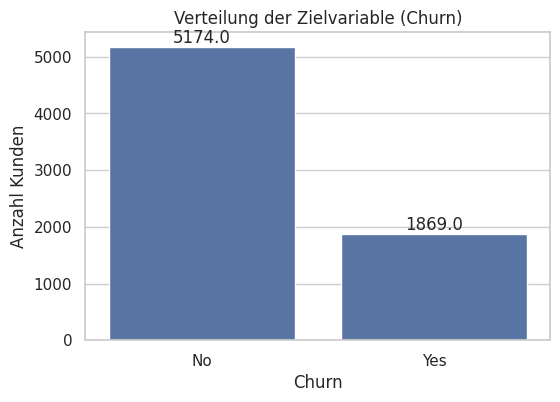

In [24]:
# Quelle: Claude
churn_abs = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

verteilung = pd.DataFrame({"Absolut": churn_abs, "Prozent": churn_pct.round(1)})
print(verteilung)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Churn", order=["No", "Yes"])
ax.set_title("Verteilung der Zielvariable (Churn)")
ax.set_ylabel("Anzahl Kunden")
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

**Beobachtung:** Etwa **27 % Churn (Yes)** gegenüber **73 % Nicht-Churn (No)** — eine **leichte
Klassenimbalance**. Konsequenz für die Bewertung: **Accuracy allein ist irreführend** (ein Modell,
das immer "No" sagt, erreicht schon ~73 %). Wir gewichten daher **F1-Score** und **ROC-AUC** stärker
und schauen genau auf die **Konfusionsmatrix** (Schritt 6).

### 1.5 Numerische und kategorische Features trennen

In [25]:
# TotalCharges für die Analyse als Zahl behandeln (Konvertierung final in Schritt 2)
df_eda = df.copy()
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")

# SeniorCitizen ist 0/1 -> technisch kategorisch, hier zur Übersicht numerisch belassen
numerische_features = ["tenure", "MonthlyCharges", "TotalCharges"]
kategorische_features = [c for c in df_eda.columns
                         if c not in numerische_features + ["customerID", "Churn", "SeniorCitizen"]]

print("Numerisch:", numerische_features)
print("\nKategorisch:", kategorische_features)

Numerisch: ['tenure', 'MonthlyCharges', 'TotalCharges']

Kategorisch: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 1.6 Visualisierung 1 — Verteilung der numerischen Features (Histogramme)

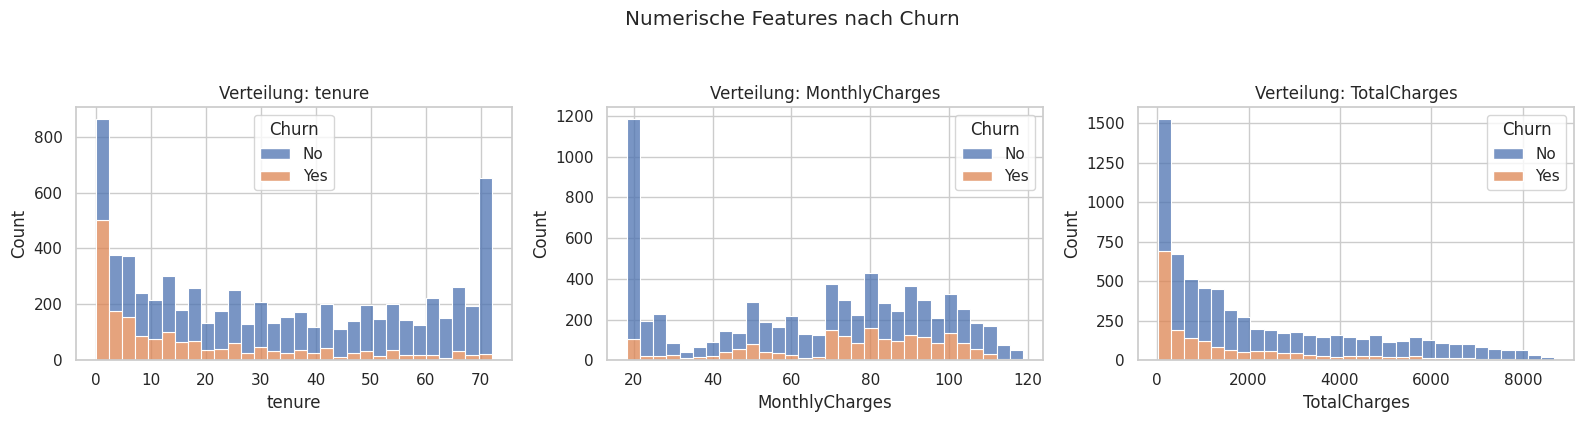

In [26]:
# Quelle: Claude
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, numerische_features):
    sns.histplot(data=df_eda, x=feat, hue="Churn", bins=30, kde=False,
                 multiple="stack", ax=ax)
    ax.set_title(f"Verteilung: {feat}")
fig.suptitle("Numerische Features nach Churn", y=1.05)
plt.tight_layout()
plt.show()

**Beobachtung:** Kunden mit **niedrigem `tenure`** (kurze Vertragsdauer) und **hohen
`MonthlyCharges`** kündigen sichtbar häufiger. `tenure` wirkt damit als starker Schutzfaktor:
je länger jemand dabei ist, desto seltener kündigt er.

### 1.7 Visualisierung 2 — Kategorische Features (Balkendiagramme)

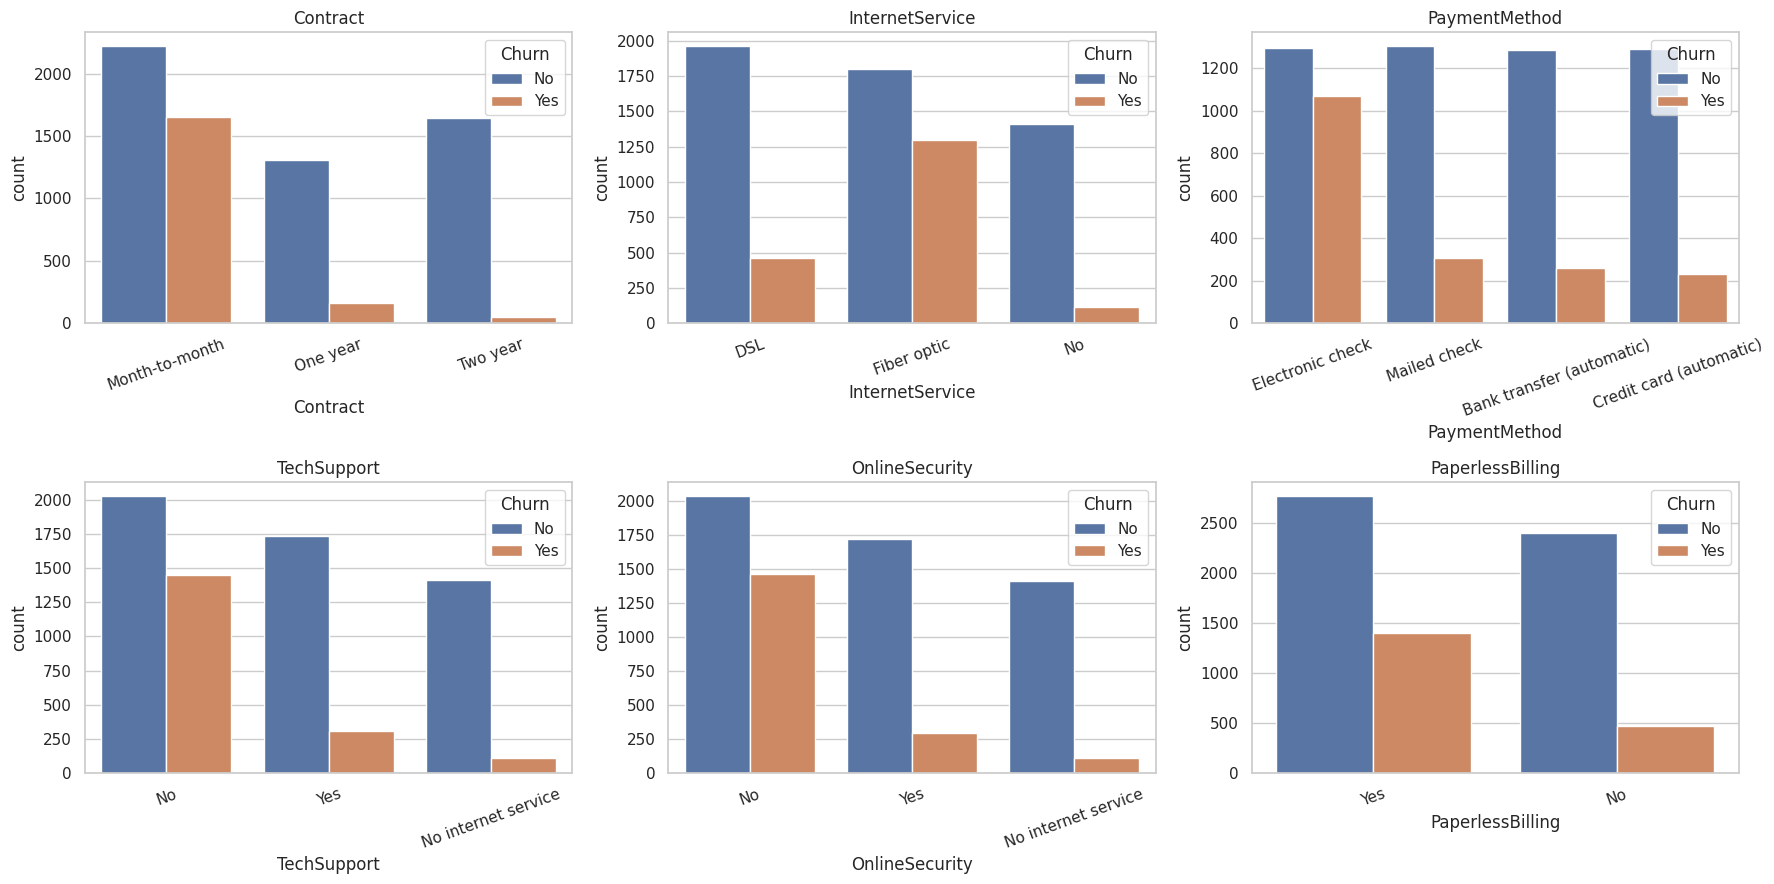

In [27]:
# Auswahl besonders interessanter kategorischer Features
wichtige_kat = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
                "OnlineSecurity", "PaperlessBilling"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, feat in zip(axes.ravel(), wichtige_kat):
    sns.countplot(data=df_eda, x=feat, hue="Churn", ax=ax)
    ax.set_title(feat)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### 1.8 Visualisierung 3 — Korrelationsmatrix

Für die Korrelationsmatrix kodieren wir alle Features numerisch (One-Hot bzw. 0/1). Das dient
**nur der Exploration** — das eigentliche, leakage-freie Encoding passiert in Schritt 2.

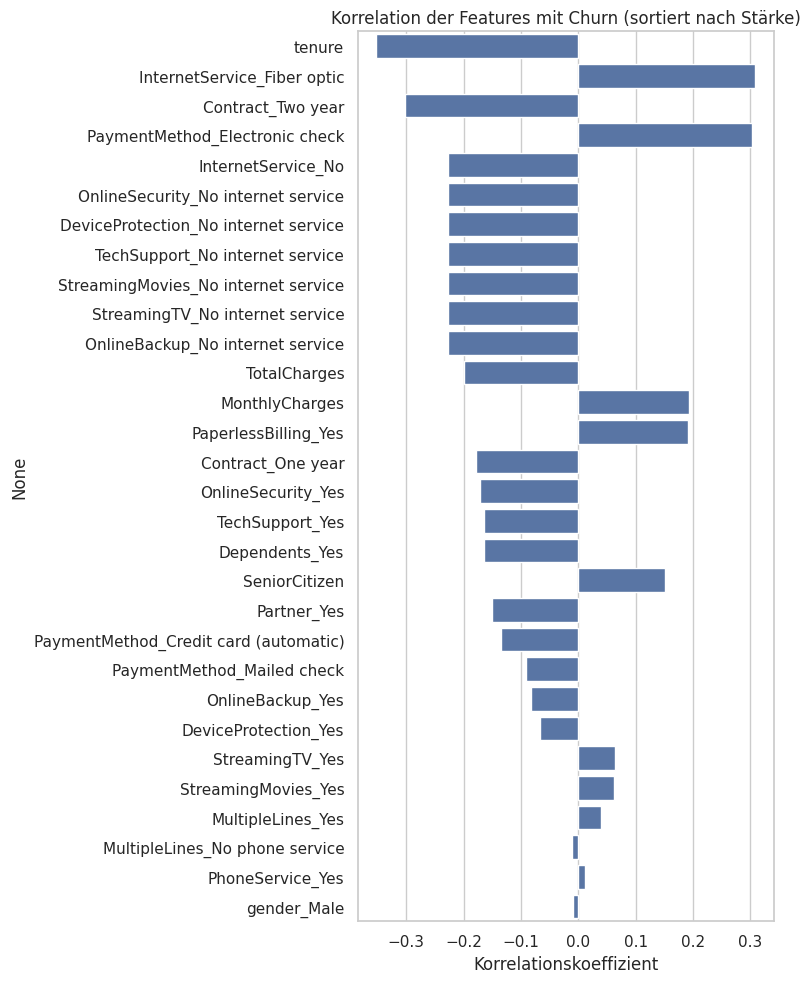

Top 10 Features nach |Korrelation| mit Churn:
tenure                                 -0.352229
InternetService_Fiber optic             0.308020
Contract_Two year                      -0.302253
PaymentMethod_Electronic check          0.301919
InternetService_No                     -0.227890
OnlineSecurity_No internet service     -0.227890
DeviceProtection_No internet service   -0.227890
TechSupport_No internet service        -0.227890
StreamingMovies_No internet service    -0.227890
StreamingTV_No internet service        -0.227890
Name: Churn, dtype: float64


In [28]:
# Quelle: Claude
df_corr = df_eda.drop(columns=["customerID"]).copy()
df_corr["Churn"] = (df_corr["Churn"] == "Yes").astype(int)
df_corr = pd.get_dummies(df_corr, drop_first=True)

# Korrelation aller Features mit der Zielvariable, nach Stärke sortiert
corr_mit_churn = df_corr.corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=corr_mit_churn.values, y=corr_mit_churn.index)
plt.title("Korrelation der Features mit Churn (sortiert nach Stärke)")
plt.xlabel("Korrelationskoeffizient")
plt.tight_layout()
plt.show()

print("Top 10 Features nach |Korrelation| mit Churn:")
print(corr_mit_churn.head(10))

### 1.9 Visualisierung 4 — Churn-Rate je Kategorie (Zusammenhang Feature ↔ Ziel)

Statt nur absoluter Häufigkeiten zeigen wir die **Kündigungsquote pro Ausprägung** — das macht
den Effekt eines Features direkt sichtbar.

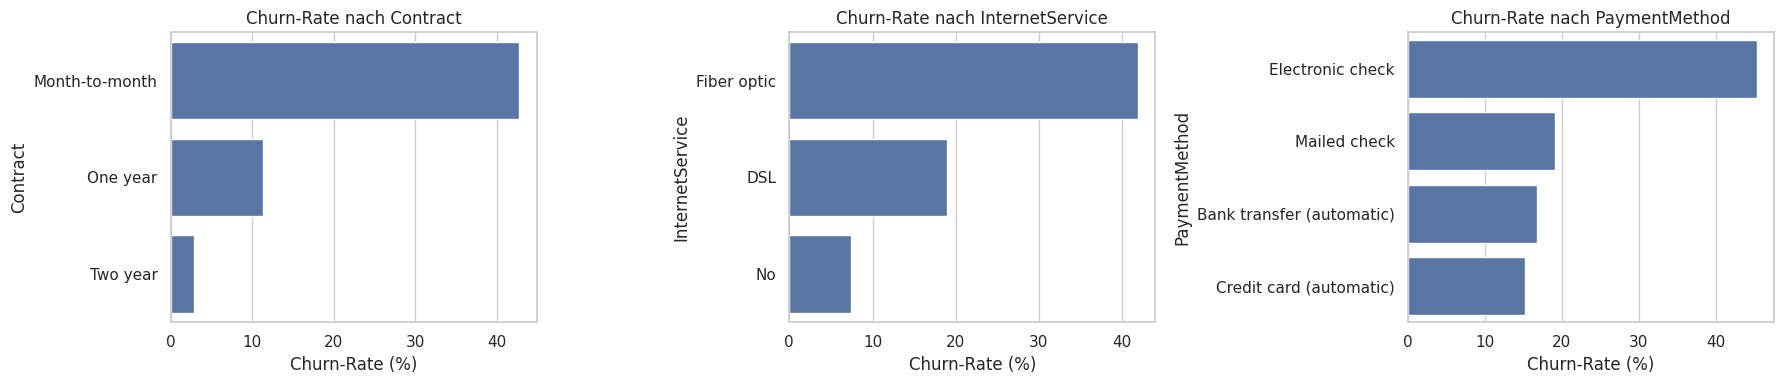

In [29]:
churn_num = (df_eda["Churn"] == "Yes").astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, feat in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    rate = churn_num.groupby(df_eda[feat]).mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax)
    ax.set_title(f"Churn-Rate nach {feat}")
    ax.set_xlabel("Churn-Rate (%)")
plt.tight_layout()
plt.show()

### 1.10 Welche Features erscheinen besonders relevant?

_(Eigene Einschätzung der Gruppe — auf Basis der Visualisierungen oben. Entwurf, bitte prüfen/anpassen.)_

Auf Basis der Analyse erscheinen folgende Features besonders relevant für eine Kündigung:

- **`Contract` (Vertragsart):** Stärkster Treiber. Monatsverträge ("Month-to-month") haben eine
  deutlich höhere Churn-Rate als 1- oder 2-Jahres-Verträge — langfristige Bindung schützt.
- **`tenure` (Vertragsdauer):** Klarer Schutzfaktor. Neukunden kündigen früh am häufigsten.
- **`MonthlyCharges` (monatliche Kosten):** Höhere Kosten gehen mit höherem Churn einher.
- **`InternetService` = Fiber optic:** Auffällig hohe Churn-Rate (mögliche Unzufriedenheit/Preis).
- **`PaymentMethod` = Electronic check:** Überdurchschnittlich hohe Kündigungsquote.
- **Zusatzdienste** wie `TechSupport`, `OnlineSecurity` (= "No"): fehlende Services erhöhen Churn.

**Begründung:** Diese Einschätzung stützt sich auf (a) die Balken der Churn-Raten je Kategorie
(1.9), (b) die nach Stärke sortierte Korrelation mit der Zielvariable (1.8) und (c) die
Histogramme der numerischen Features (1.6). Features wie `gender` zeigen dagegen kaum Zusammenhang
mit Churn.

---
# Schritt 2 — Preprocessing und Datenvorbereitung

_(Noch zu bearbeiten.)_ Geplante Teilaufgaben:
- Fehlende Werte in `TotalCharges` (11 Stück, tenure=0) behandeln **und Entscheidung begründen**
- `customerID` entfernen
- Kategorische Features kodieren — **One-Hot vs. Label Encoding mit Begründung**
- Stratifizierter **Train/Validation/Test-Split (70/15/15)**
- Features skalieren — **welche und warum?**
- **Kernfrage:** Darf der Scaler auf dem gesamten Datensatz gefittet werden? → Nein (Data Leakage);
  `fit` nur auf Train, dann `transform` auf Val/Test.

---
# Schritt 3 — Klassische Modelle

_(Noch zu bearbeiten.)_ Geplante Teilaufgaben:
- Drei klassische Modelle mit **Default-Parametern** trainieren
  (Logistic Regression + ein Baum-Modell + k-NN/SVM)
- Evaluation mit **5-facher stratifizierter Kreuzvalidierung**
- Pro Modell: **Accuracy, F1 (weighted), ROC-AUC**
- Ergebnisse in die Vergleichstabelle (Schritt 6) eintragen + Kurzkommentar

---
# Schritt 4 — Variante A: Einfaches neuronales Netz

_(Noch zu bearbeiten.)_ Architektur: `Input → Dense(64, relu) → Dense(1, sigmoid)`
- Optimizer **Adam**, Loss `binary_crossentropy`, max. 100 Epochen, batch_size 32
- Early Stopping: `monitor='val_loss', patience=5, restore_best_weights=True`
- Lernkurven (Loss/Accuracy) plotten + Overfitting/Underfitting kommentieren

---
# Schritt 5 — Variante B: Tieferes Netz mit Regularisierung

_(Noch zu bearbeiten.)_ Architektur:
`Input → Dense(64, relu) → Dropout(0.3) → Dense(32, relu) → Dense(1, sigmoid)`
- Optimizer **SGD** (statt Adam), sonst identisch zu A
- Lernkurven mit Variante A vergleichen (Effekt Dropout, SGD vs. Adam)
- **Kernfrage:** Warum ist Variante B nicht automatisch besser als Variante A?

---
# Schritt 6 — Modellvergleich, Optimierung und finale Evaluation

_(Noch zu bearbeiten.)_

| Modell | Typ | Accuracy | F1 | Notizen |
|--------|-----|----------|----|---------|
| Logistic Regression | klassisch | ___ | ___ | |
| Decision Tree / RF / XGB | klassisch | ___ | ___ | |
| k-NN / SVM | klassisch | ___ | ___ | |
| MLP Variante A | neuronal | ___ | ___ | |
| MLP Variante B | neuronal | ___ | ___ | |

- Hyperparameter-Optimierung des besten Modells (GridSearchCV / KerasTuner)
- **Finale Evaluation auf dem Testset — genau einmal!**
- Konfusionsmatrix interpretieren (False Positives vs. False Negatives im Praxiskontext)

---
# Schritt 7 — Reflexion und Fazit

_(Eigenständig von der Gruppe zu verfassen.)_
- Welches Modell für den Produktiveinsatz — und warum?
- Was hat überrascht? Wo liegen die Grenzen des Modells?
- Was würdet ihr mit mehr Zeit/Daten/Ressourcen anders machen?
- Bonus: Hätte ein CNN oder Transfer Learning geholfen — warum (nicht)?